# Lab 4

> Exercises 1-3 are fresh implementations of standard toy setups; the sources for each
> task are credited at the start of its exercise. The bonus in Exercise 2 is adapted
> from the `lecture_i2dl` course's VAE lab (Lab 10).

This lab is a recap of Session 6 (RNN, VAE, GAN), one exercise per model family. Each
exercise is a small, real, verified experiment that makes a claim from that session's
slides visible on actual data, rather than just re-explaining the claim.

> **Instructor timing (2h session).** ~10 min: intro (this page) and setup. ~20 min:
> Exercise 1 - vanilla RNN vs. LSTM on a long-range dependency task. ~45 min: Exercise
> 2 - a 2D-latent VAE on MNIST (reparameterization trick and the full VAE loss), plus a
> short bonus on posterior collapse. ~35 min: Exercise 3 - a full GAN training step on a
> toy 2D distribution, and what its training instability actually looks like. ~10 min
> buffer.

## Setup

These labs are designed to run on [Google Colab](https://colab.research.google.com/) -
no local Python install needed. Open this notebook via Colab's GitHub loader
(`colab.research.google.com/github/KarikS/lecture_advanced_ai_ml/blob/main/<path-to-this-notebook>`)
or File > Open notebook > GitHub tab, repo `KarikS/lecture_advanced_ai_ml`, then run
the cell below once per session. Running the notebook locally instead (e.g. via the
`exercises/python/` venv described in that folder's README) works unchanged - the cell
below is a no-op there. Nothing in this lab needs a GPU - every experiment below trains
in well under a minute on CPU.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import os
    if not os.path.exists('lecture_advanced_ai_ml'):
        !git clone https://github.com/KarikS/lecture_advanced_ai_ml.git

## Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib_inline.backend_inline import set_matplotlib_formats
from torch import nn, Tensor
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

set_matplotlib_formats('png', 'pdf')
torch.manual_seed(0)

DATA_DIR = (
    Path('lecture_advanced_ai_ml/exercises/python/data') if IN_COLAB else Path('../data')
)

## Exercise 1: Vanilla RNN vs. LSTM on a Long-Range Dependency Task

> Task adapted from the "adding problem", a standard synthetic benchmark for long-range
> dependencies introduced in Hochreiter & Schmidhuber (1997), *Long Short-Term Memory*,
> Neural Computation 9(8) - the same paper that introduced the LSTM cell itself.

Session 6 explained *why* vanilla RNNs struggle with long sequences (vanishing
gradients through repeated multiplication by the same recurrent weight matrix) and
*why* LSTM's gating mechanism fixes this. This exercise makes that claim visible on
data instead of just asserting it.

**The task:** the input is a sequence of length $T$ with two channels. Channel 0 is a
random value in $[0,1]$ at every timestep. Channel 1 is a mask that is exactly $1$ at
two randomly chosen timesteps and $0$ everywhere else. The target is the sum of the two
channel-0 values at the two marked positions. To solve this, a model has to *remember*
a value it saw early in the sequence until it sees the second marker, however far away
that is - exactly the kind of long-range dependency vanishing gradients make hard.

A model that has learned nothing always predicts the mean of two independent
$\text{Uniform}(0,1)$ values, giving a mean-squared error around $\text{Var}(2 \cdot U)=
2/12 \approx 0.167$. Beating this baseline means the model is actually using the marked
values.

In [3]:
def make_adding_batch(batch_size: int, seq_len: int) -> tuple[Tensor, Tensor]:
    values = torch.rand(batch_size, seq_len, 1)
    mask = torch.zeros(batch_size, seq_len, 1)
    for b in range(batch_size):
        i1, i2 = torch.randperm(seq_len)[:2]
        mask[b, i1, 0] = 1.0
        mask[b, i2, 0] = 1.0
    x = torch.cat([values, mask], dim=-1)  # (batch, seq_len, 2)
    y = (values * mask).sum(dim=1).squeeze(-1)  # (batch,)
    return x, y

# At length 30 a vanilla RNN still sometimes learns the task within this lab's training
# budget (2 of 5 seeds in testing); at 50 it reliably fails while the LSTM still succeeds.
SEQ_LEN = 50
x_example, y_example = make_adding_batch(batch_size=1, seq_len=SEQ_LEN)
print('value channel:', x_example[0, :, 0].round(decimals=2).tolist())
print('mask channel: ', x_example[0, :, 1].int().tolist())
print('target (sum of the two marked values):', y_example.item())

value channel: [0.5, 0.7699999809265137, 0.09000000357627869, 0.12999999523162842, 0.3100000023841858, 0.6299999952316284, 0.49000000953674316, 0.8999999761581421, 0.46000000834465027, 0.6299999952316284, 0.3499999940395355, 0.4000000059604645, 0.019999999552965164, 0.17000000178813934, 0.28999999165534973, 0.5199999809265137, 0.699999988079071, 0.800000011920929, 0.1599999964237213, 0.2800000011920929, 0.6800000071525574, 0.9200000166893005, 0.4000000059604645, 0.8700000047683716, 0.41999998688697815, 0.550000011920929, 0.949999988079071, 0.03999999910593033, 0.1899999976158142, 0.3700000047683716, 0.3100000023841858, 0.9300000071525574, 0.18000000715255737, 0.27000001072883606, 0.15000000596046448, 0.029999999329447746, 0.20999999344348907, 0.9300000071525574, 0.7200000286102295, 0.7400000095367432, 0.5299999713897705, 0.23999999463558197, 0.5799999833106995, 0.029999999329447746, 0.14000000059604645, 0.23999999463558197, 0.8199999928474426, 0.7900000214576721, 0.2800000011920929, 0.

Now the model. `nn.RNN` and `nn.LSTM` share the same interface in PyTorch (same
constructor arguments, same output shapes), so the exact same wrapper class works for
both - we only change which one gets passed in.

In [4]:
class SeqRegressor(nn.Module):
    def __init__(self, recurrent_layer: nn.Module, hidden_size: int):
        super().__init__()
        self.rnn = recurrent_layer
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: Tensor) -> Tensor:
        out, _ = self.rnn(x)
# TODO: We only care about the model's output after it has seen the whole
# sequence. `out` has shape (batch, seq_len, hidden_size) - select the last
# timestep, then pass it through `self.head` and squeeze the last dimension.

**Question:** Why the *last* timestep specifically, rather than e.g. averaging `out` over the
whole sequence?

Here is the training loop. Since there is no fixed dataset - we generate a fresh random
batch every step - there is no notion of an "epoch"; we just train for a fixed number
of steps.

In [5]:

def train_seq_model(recurrent_layer: nn.Module, hidden_size: int, steps: int = 3000,
                     batch_size: int = 64, seq_len: int = SEQ_LEN) -> list[float]:
    model = SeqRegressor(recurrent_layer, hidden_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    losses = []

    for step in range(steps):
        x, y = make_adding_batch(batch_size, seq_len)

# TODO: Do a forward pass, compute the MSE loss between the prediction and
# y, then backpropagate and take an optimizer step - the same three-line
# pattern as every training loop so far in this course.

        losses.append(float(loss))
        if (step + 1) % 500 == 0:
            print('STEP:\t{:5} / {:5}\tLOSS:\t{:.4f}'.format(step + 1, steps, float(loss)), end='\r')
    print()
    return losses

HIDDEN_SIZE = 32

print('Training vanilla RNN...')
rnn_losses = train_seq_model(nn.RNN(input_size=2, hidden_size=HIDDEN_SIZE, batch_first=True), HIDDEN_SIZE)

print('Training LSTM...')
lstm_losses = train_seq_model(nn.LSTM(input_size=2, hidden_size=HIDDEN_SIZE, batch_first=True), HIDDEN_SIZE)

In [6]:
plt.plot(rnn_losses, label='vanilla RNN', alpha=0.7)
plt.plot(lstm_losses, label='LSTM', alpha=0.7)
plt.axhline(2 / 12, color='gray', linestyle='--', label='"predict the mean" baseline')
plt.xlabel('training step')
plt.ylabel('MSE loss')
plt.legend()
plt.yscale('log')
plt.show()

print('Final 100-step average loss - RNN: {:.4f}, LSTM: {:.4f}'
      .format(np.mean(rnn_losses[-100:]), np.mean(lstm_losses[-100:])))

At sequence length 50, the vanilla RNN should get stuck right around the 0.167
"predict-the-mean" baseline - it never manages to bridge the gap between the two
markers. The LSTM should drop far below it (to roughly 0.005-0.03, depending on the
run), because its gating
mechanism gives it an (approximately) uninterrupted path to carry the first marked
value forward until it is needed. This is the vanishing-gradient problem from Session 6,
made visible on data rather than argued from the recurrence equations alone.

## Exercise 2: A 2D-Latent VAE on MNIST

> Standard toy VAE setup (small MLP encoder/decoder, 2D latent space specifically so it
> can be plotted directly) - the same architecture family as the original VAE paper's
> own MNIST experiments (Kingma & Welling, 2014, *Auto-Encoding Variational Bayes*),
> freshly implemented for this course.

Session 6 introduced the VAE's two-term loss (reconstruction + KL-to-prior) and the
reparameterization trick (sampling would block backpropagation, so instead we sample a
fixed $\epsilon \sim \mathcal{N}(0, 1)$ and compute $z = \mu + \epsilon \cdot \sigma$,
which keeps $\mu$ and $\sigma$ inside the computational graph). This exercise trains a
real VAE and looks at what the resulting latent space actually looks like.

We use a deliberately small latent size - just 2 dimensions - not because that's a good
choice in general, but so that we can scatter-plot the entire latent space directly,
with no dimensionality reduction needed.

In [7]:
mnist_train = MNIST(root='.data', train=True, download=True, transform=ToTensor())
mnist_test = MNIST(root='.data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True, num_workers=2)

In [8]:
LATENT_DIM = 2

class VAE(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
        )
        self.to_mu = nn.Linear(64, latent_dim)
        self.to_logvar = nn.Linear(64, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
        )

    def encode(self, x: Tensor) -> tuple[Tensor, Tensor]:
        h = self.encoder(x)
        return self.to_mu(h), self.to_logvar(h)

    def reparameterize(self, mu: Tensor, logvar: Tensor) -> Tensor:
        std = torch.exp(0.5 * logvar)
        return (
# TODO: Implement the reparameterization trick: sample
# eps ~ N(0, 1) with torch.randn_like(std), and return mu + eps * std.
        )

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor, Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

**Question:** If we skipped sampling entirely and just set $z=\mu$ during training, what would
break?

Now the loss. For one input $x$ with encoder outputs $\mu, \log\sigma^2 \in \mathbb{R}^d$
and reconstruction $\hat{x}$, it is the sum of two terms:

- **Reconstruction:** MNIST pixels lie in $[0, 1]$ and the decoder ends in a sigmoid, so
we treat each pixel as a Bernoulli probability and use the binary cross-entropy, summed
over all 784 pixels: $-\sum_j \big[x_j \log \hat{x}_j + (1 - x_j) \log(1 - \hat{x}_j)\big]$.
- **KL to the prior:** for a diagonal Gaussian encoder and a $\mathcal{N}(0, I)$ prior, the KL
divergence has a closed form,
$$
D_{KL}\big(\mathcal{N}(\mu, \sigma^2) \,\|\, \mathcal{N}(0, I)\big)
= -\frac{1}{2} \sum_{i=1}^{d} \left(1 + \log\sigma_i^2 - \mu_i^2 - \sigma_i^2\right).
$$

Both terms are summed per example and then averaged over the batch.

**Question:** Why does the encoder output $\log\sigma^2$ instead of $\sigma$ directly?

In [9]:

def vae_loss(x_hat: Tensor, x: Tensor, mu: Tensor, logvar: Tensor) -> tuple[Tensor, Tensor, Tensor]:
# TODO: Compute both terms from the formulas above, each summed over pixels /
# latent dimensions and averaged over the batch (divide by x.size(0)).
# Hint: F.binary_cross_entropy(..., reduction='sum') gives the summed BCE;
# logvar is log(sigma^2), so sigma^2 is logvar.exp().
    return recon + kl, recon, kl

model = VAE()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in train_loader:
        x = x.view(x.size(0), -1)

# TODO: Do a forward pass through the model, compute the loss with
# vae_loss, then backpropagate and take an optimizer step.

        total_loss += float(loss) * x.size(0)
        total_recon += float(recon) * x.size(0)
        total_kl += float(kl) * x.size(0)
        n += x.size(0)
    print('EPOCH:\t{:2}\tLOSS:\t{:.2f}\tRECON:\t{:.2f}\tKL:\t{:.2f}'
          .format(epoch, total_loss / n, total_recon / n, total_kl / n))

First, a sanity check: do reconstructions actually look like the input digits?

In [10]:
model.eval()
sample_x = torch.stack([mnist_test[i][0] for i in range(8)]).view(8, -1)
with torch.no_grad():
    sample_x_hat, _, _ = model(sample_x)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(sample_x[i].view(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(sample_x_hat[i].view(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('input')
axes[1, 0].set_ylabel('reconstruction')
plt.show()

Now the more interesting question: what does the 2D latent space actually look like?
We encode the whole test set and scatter-plot every point, colored by its true digit
label (which the VAE never saw during training - it's a purely unsupervised model).

In [11]:
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)
all_mu, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        mu, _ = model.encode(x.view(x.size(0), -1))
        all_mu.append(mu)
        all_labels.append(y)
all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(6, 6))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', s=3, alpha=0.6)
plt.colorbar(scatter, label='digit')
plt.xlabel('latent dim 1')
plt.ylabel('latent dim 2')
plt.title('Test-set digits in the learned 2D latent space')
plt.show()

Even though the VAE was never told which digit is which, digits of the same class
should form loosely separated regions - the model organizes the latent space by visual
similarity because that's what makes reconstruction easiest, and visual similarity
correlates strongly with digit identity. This is the "manifold learning" idea from
Session 6: the model discovers a low-dimensional structure in the data on its own.

### Bonus: Posterior Collapse

> This specific demonstration - deliberately unbalancing the loss to break the model,
> rather than just training it correctly - is adapted from `lecture_i2dl`'s Lab 10 VAE
> exercise.

The two terms in the VAE loss pull in opposite directions: reconstruction wants
$z$ to carry as much information as possible about $x$; the KL term wants $z$'s
distribution to stay close to a plain $\mathcal{N}(0,1)$, which carries *no* information
about $x$. If the KL term is weighted too heavily relative to reconstruction, the
optimizer takes the easy way out: it satisfies the KL term perfectly by ignoring the
input and always outputting $\mu \approx 0, \sigma \approx 1$, and reconstruction
quality collapses to "the average-looking digit," regardless of the input. This is
called **posterior collapse**.

In [12]:

def train_vae(kl_weight: float, epochs: int = 3) -> nn.Module:
    model = VAE()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        total_recon, total_kl, n = 0.0, 0.0, 0
        for x, _ in train_loader:
            x = x.view(x.size(0), -1)
            optimizer.zero_grad()
            x_hat, mu, logvar = model(x)
            _, recon, kl = vae_loss(x_hat, x, mu, logvar)
            (recon + kl_weight * kl).backward()
            optimizer.step()
            total_recon += float(recon) * x.size(0)
            total_kl += float(kl) * x.size(0)
            n += x.size(0)
        print('kl_weight={:.0f}\tepoch {:2}\trecon={:.2f}\tkl={:.2f}'
              .format(kl_weight, epoch + 1, total_recon / n, total_kl / n))
    return model

vae_collapsed = train_vae(kl_weight=50.0)

In [13]:
vae_collapsed.eval()
with torch.no_grad():
    sample_x_hat_collapsed, _, _ = vae_collapsed(sample_x)

fig, axes = plt.subplots(3, 8, figsize=(12, 4.5))
for i in range(8):
    axes[0, i].imshow(sample_x[i].view(28, 28), cmap='gray')
    axes[1, i].imshow(sample_x_hat[i].view(28, 28), cmap='gray')
    axes[2, i].imshow(sample_x_hat_collapsed[i].view(28, 28), cmap='gray')
    for row in range(3):
        axes[row, i].axis('off')
plt.show()

The bottom row (KL weighted 50x too heavily) should look like the same blurry,
average-looking blob for every input - the model gave up on reconstruction entirely to
minimize the now-dominant KL term. Don't confuse this with GAN *mode collapse*
(mentioned in Exercise 3): the names sound similar, but the mechanism is completely
different (a KL term overwhelming reconstruction here, vs. a generator finding one easy
way to fool a discriminator there).

## Exercise 3: A GAN on a Toy 2D Distribution, and Its Training Instability

> Task setup (a ring of well-separated 2D Gaussians as the "real" data distribution) is
> a standard toy benchmark for studying GAN training dynamics and mode collapse, used
> in this form in e.g. Metz et al. (2017), *Unrolled Generative Adversarial Networks*
> ([arXiv:1611.02163](https://arxiv.org/abs/1611.02163)) - freshly implemented for
> this course, not copied from that paper's code.

Session 6's "Challenges for GAN Optimization" section discussed why GAN training is
harder than ordinary supervised training: two networks are optimized against each
other, and there is no single loss that monotonically decreases as training
"succeeds". This exercise makes that concrete by watching a GAN's output distribution
change *during* training, not just looking at the final result.

**The real data:** points sampled from 8 Gaussian blobs arranged evenly around a
circle. A generator that has properly learned this distribution should produce points
spread across all 8 blobs, in the correct proportions.

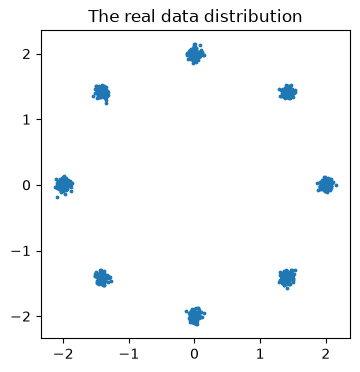

In [14]:
N_MODES = 8
RING_RADIUS = 2.0
MODE_STD = 0.05

def sample_real(batch_size: int) -> Tensor:
    angles = 2 * np.pi * np.random.randint(0, N_MODES, size=batch_size) / N_MODES
    centers = np.stack([RING_RADIUS * np.cos(angles), RING_RADIUS * np.sin(angles)], axis=1)
    points = centers + np.random.randn(batch_size, 2) * MODE_STD
    return torch.tensor(points, dtype=torch.float32)

real_sample = sample_real(1000)
plt.figure(figsize=(4, 4))
plt.scatter(real_sample[:, 0], real_sample[:, 1], s=3)
plt.title('The real data distribution')
plt.gca().set_aspect('equal')
plt.show()

In [15]:
class Generator(nn.Module):
    def __init__(self, noise_dim: int = 2, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, z: Tensor) -> Tensor:
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)

Now the training step. Every iteration alternates two updates: the discriminator is
trained to tell real points from the generator's (detached) fake points, then the
generator is trained to make the discriminator classify its fakes as real. This is the
minimax game from Session 6, using the "non-saturating" generator loss (maximize
$\log D(G(z))$ instead of minimizing $\log(1-D(G(z)))$), which is what's actually used
in practice since it gives much stronger gradients early in training, when $D$ can
easily tell fakes apart.

**Question:** Why are the fakes detached in the discriminator step but not in the
generator step?

In [16]:
NOISE_DIM = 2
# Both RNGs: sample_real() draws from numpy, the networks and noise from torch.
torch.manual_seed(0)
np.random.seed(0)
generator = Generator(NOISE_DIM)
discriminator = Discriminator()
opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()

def gan_train_step(batch_size: int = 256) -> tuple[float, float]:
# TODO: Implement one full GAN training iteration.
# 1. Discriminator step: sample `batch_size` real points with sample_real() and
# `batch_size` fake points from the generator (noise: torch.randn with NOISE_DIM
# columns). Detach the fakes. The loss is `bce` with target 1 for real and 0
# for fake (summed); then zero_grad / backward / step with opt_d.
# 2. Generator step: draw fresh noise, generate fakes WITHOUT detaching, and use the
# non-saturating loss - `bce` with target 1 on the discriminator's output for the
# fakes; then zero_grad / backward / step with opt_g.
# Name the two losses `loss_d` and `loss_g`.

    return float(loss_d), float(loss_g)

In [17]:

STEPS = 1500
SNAPSHOT_STEPS = {50, 200, 400, 900, 1500}
snapshots = {}

for step in range(1, STEPS + 1):
    loss_d, loss_g = gan_train_step()
    if step in SNAPSHOT_STEPS:
        with torch.no_grad():
            z = torch.randn(1000, NOISE_DIM)
            snapshots[step] = generator(z).numpy()
    if step % 300 == 0:
        print('STEP:\t{:5} / {:5}\tLOSS_D:\t{:.3f}\tLOSS_G:\t{:.3f}'
              .format(step, STEPS, loss_d, loss_g), end='\r')
print()

In [18]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))
for ax, (step, points) in zip(axes, sorted(snapshots.items())):
    ax.scatter(real_sample[:, 0], real_sample[:, 1], s=2, alpha=0.15, label='real')
    ax.scatter(points[:, 0], points[:, 1], s=2, color='tab:red', label='generated')
    ax.set_title(f'step {step}')
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
axes[0].legend(loc='upper left', markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

Look at how the generated distribution moves between snapshots. Early on (steps 50-400)
it does not improve smoothly - it jumps between completely different shapes: a blob in
one region, then a diagonal smear, then points scattered over the whole square. Each
jump is the generator chasing whatever the discriminator currently penalizes least, and
the discriminator then moving its decision boundary in response. Meanwhile the printed
losses barely change at all - they tell you almost nothing about how well the generator
is doing.

By steps 900-1500 the generator has found the ring, with denser clusters at the eight
modes, but it also keeps a thin trail of points *between* them. That is not undertraining:
the generator is a continuous function of a 2D Gaussian noise vector, so the set of
points it can produce is connected - it cannot produce eight perfectly separate blobs, only
a connected shape that concentrates mass near them.

This run doesn't show **mode collapse** (the generator covering only a few of the eight
modes). That failure is well known in this kind of setup, but whether it happens depends
on the seed and hyperparameters - try changing the seeds in the cell that creates the
two networks, or the learning rates, and see if you can trigger it.

**Question:** This lab's VAE (Exercise 2) never showed anything like this - its loss decreased
smoothly, epoch over epoch. Why does a GAN's training look so much less well-behaved?

## Conclusion

Here's what you should take away from this lab:

 - Vanilla RNNs really do struggle with long-range dependencies, and LSTMs really do
fix it - not just in theory, but as a measurable gap on a task literally designed to
require remembering something across a long delay (Exercise 1).
 - The reparameterization trick (Exercise 2) is what lets a VAE be trained by ordinary
backpropagation despite having a random sampling step in the middle - and the resulting
latent space organizes itself by similarity even though the model was never given
labels.
 - GAN training (Exercise 3) is a genuinely different kind of optimization problem from
the supervised training in Labs 1, 3, and this lab's own VAE exercise: two networks
chasing a moving target. That is why the generated distribution jumps around during
training and why the loss values are a poor progress signal - neither is a sign that
something is broken.